<a href="https://colab.research.google.com/github/Sana-Abzakh/SecStruct-calculator-V4/blob/main/User's_plotting_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This script is a data visualization tool that takes two spreadsheet files as input and produces a publication-ready graph. The first file contains the raw measurement data and its mathematical breakdown, while the second file contains peaks names and peaks centtroids. It automatically reads, processes, and plots the data with a color-coded chart where each contributing component is displayed as a shaded region. The result is saved as a high-resolution image file.

**Note: You can upload .csv, .xlsx, or .xls for either the main or centroid file.**

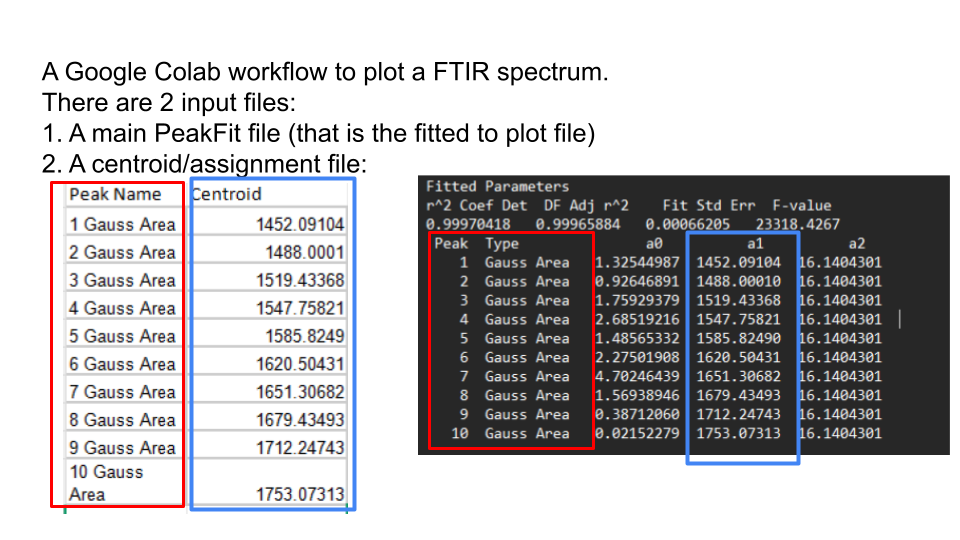

Upload your MAIN data file (with peaks):


Saving Preeclampsia  - main (1).csv to Preeclampsia  - main (1).csv

Upload your CENTROID file:


Saving Preeclampsia  - center (1).csv to Preeclampsia  - center (1).csv
Found 9 peak columns in main file
Legend names:
  Peak 1: 1493 cm⁻¹
  Peak 2: 1521 cm⁻¹
  Peak 3: 1548 cm⁻¹
  Peak 4: 1578 cm⁻¹
  Peak 5: 1605 cm⁻¹
  Peak 6: 1632 cm⁻¹
  Peak 7: 1657 cm⁻¹
  Peak 8: 1686 cm⁻¹
  Peak 9: 1719 cm⁻¹


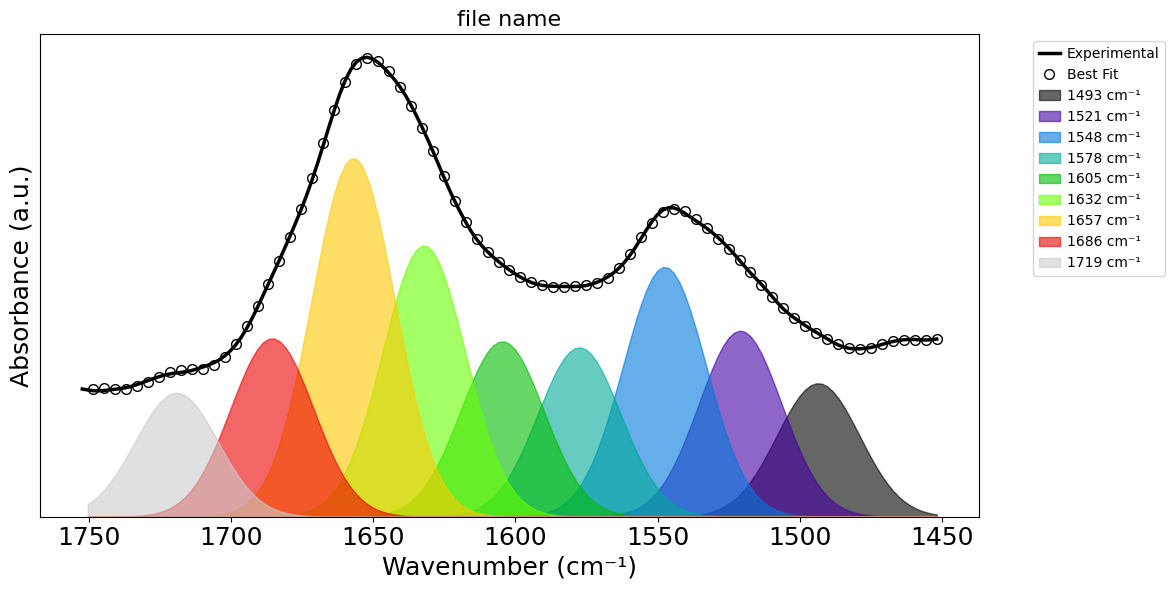

✓ Plot saved as: Preeclampsia  - main (1)_with_assignments.png


<Figure size 640x480 with 0 Axes>

In [1]:
!pip install xlrd openpyxl -q
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

def load_data(filename, skiprows=0):
    ext = os.path.splitext(filename)[1].lower()
    if ext == '.csv':
        df = pd.read_csv(filename, skiprows=skiprows)
    elif ext == '.xls':
        df = pd.read_excel(filename, skiprows=skiprows, engine='xlrd')
    elif ext == '.xlsx':
        df = pd.read_excel(filename, skiprows=skiprows, engine='openpyxl')
    else:
        raise ValueError(f"Unsupported file type: {ext}")

    df.columns = [str(c).strip() for c in df.columns]
    return df

def find_column(df, candidates):
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    return None

def normalize_spaces(s):
    return re.sub(r'\s+', ' ', str(s)).strip()

print("Upload your MAIN data file (with peaks):")
uploaded_main = files.upload()
main_filename = list(uploaded_main.keys())[0]

print("\nUpload your CENTROID file:")
uploaded_centroid = files.upload()
centroid_filename = list(uploaded_centroid.keys())[0]

base_name = os.path.splitext(main_filename)[0]
df_main = load_data(main_filename, skiprows=1)
df_centroid = load_data(centroid_filename)

peak_name_col = find_column(df_centroid, ['Peak Name', 'Peak Nam', 'PeakName'])
centroid_col = find_column(df_centroid, ['Centroid'])
assignment_col = find_column(df_centroid, ['Assignment'])

if peak_name_col is None or centroid_col is None:
    raise KeyError(
        f"Could not find required columns in centroid file. "
        f"Found columns: {list(df_centroid.columns)}"
    )
main_cols_normalized = {normalize_spaces(col): col for col in df_main.columns}

centroid_dict = {}
assignment_dict = {}
for idx, row in df_centroid.iterrows():
    peak_name = row[peak_name_col]
    centroid_value = row[centroid_col]
    assignment_value = row[assignment_col] if assignment_col else ""

    try:
        num_part = str(peak_name).split()[0]
        candidate_name = normalize_spaces(f"Peak {num_part} Gauss Area")

        if candidate_name in main_cols_normalized:
            mapped_name = main_cols_normalized[candidate_name]
        else:
            mapped_name = candidate_name

        centroid_dict[mapped_name] = centroid_value
        assignment_dict[mapped_name] = assignment_value
    except:
        centroid_dict[peak_name] = centroid_value
        assignment_dict[peak_name] = assignment_value

x_obs = df_main['X Observed']
y_obs = df_main['Y Observed']
x_fit = df_main['X Generated']
y_fit = df_main['Y Generated']

y_fit_interp = np.interp(x_obs, x_fit, y_fit)

peak_cols = [col for col in df_main.columns if 'Gauss Area' in col]

custom_names = []
for col in peak_cols:
    centroid_text = None
    assignment_text = None
    if col in centroid_dict and pd.notna(centroid_dict[col]):
        centroid_val = centroid_dict[col]
        if abs(centroid_val - round(centroid_val)) < 0.0001:
            centroid_text = f'{int(round(centroid_val))} cm⁻¹'
        else:
            centroid_text = f'{centroid_val:.1f} cm⁻¹'
    if col in assignment_dict and pd.notna(assignment_dict[col]) and str(assignment_dict[col]).strip():
        assignment_text = str(assignment_dict[col]).strip()
    if centroid_text and assignment_text:
        custom_names.append(f"{centroid_text}: {assignment_text}")
    elif centroid_text:
        custom_names.append(centroid_text)
    elif assignment_text:
        custom_names.append(assignment_text)
    else:
        custom_names.append(col)

print(f"Found {len(peak_cols)} peak columns in main file")
print("Legend names:")
for i, (col, name) in enumerate(zip(peak_cols, custom_names)):
    print(f"  Peak {i+1}: {name}")

n = len(peak_cols)
colors = plt.cm.nipy_spectral(np.linspace(0, 1, n))

plt.figure(figsize=(16,6))
plt.plot(x_obs, y_obs, '-', color='black', label='Experimental', linewidth=2.5)

skip = 2
plt.plot(x_obs[::skip], y_fit_interp[::skip], 'o', color='black', label='Best Fit',
         markersize=7, fillstyle='none', markeredgewidth=1)

for i, col in enumerate(peak_cols):
    plt.fill_between(
        x_fit,
        0,
        df_main[col],
        color=colors[i % len(colors)],
        alpha=0.6,
        label=custom_names[i]
    )

plt.xlabel('Wavenumber (cm⁻¹)', fontsize=18)
plt.ylabel('Absorbance (a.u.)', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks([])
plt.title('file name', fontsize=16) #change the name of the plot from here ##

plt.ylim(bottom=0)
plt.gca().invert_xaxis()

plt.legend(bbox_to_anchor=(1.05, 1),
           loc='upper left',
           fontsize=10,
           ncol=1,
           columnspacing=0.8,
           handlelength=1.5,
           handletextpad=0.5)

plt.tight_layout(rect=[0, 0, 0.75, 1])
plt.show()

output_filename = f'{base_name}_with_assignments.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"✓ Plot saved as: {output_filename}")